# AI-Driven Retail Demand Forecasting and Intelligent Inventory Decision Support for Food Waste Reduction
## CRISP-DM Based Notebook with EDA, Modeling, Evaluation, Recommendation Support, and Production-Oriented Forecasting Workflow

This notebook follows the **CRISP-DM methodology**:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment / Production-Oriented Forecasting Workflow

The notebook is used for academic demonstration of the analytical workflow. The modular `.py` files remain the production-style implementation for FastAPI, database storage, drift detection, automatic retraining, model versioning, and the Streamlit dashboard.


# 1. Business Understanding

Retail supermarkets face demand uncertainty because sales can change due to holidays, promotions, weather, store type, seasonal patterns, and customer purchasing behaviour. Poor forecasting can cause overstocking, stockouts, inventory imbalance, and inventory-related waste-risk situations.

The goal of this project is to develop an **AI-driven retail demand forecasting and intelligent inventory decision-support framework** that supports inventory planning, waste-risk identification, and recommendation-based operational decision-making.

The project also addresses sustainability. The Walmart dataset does not directly measure enterprise food waste, spoilage, or product disposal. Therefore, additional inventory-related variables are engineered to represent operational waste-risk conditions. The project focuses on **waste-risk identification and preventive inventory decision support rather than direct measurement of food-waste reduction**.


# 2. Data Understanding

The correct Walmart dataset contains three files:

- `train.csv`: weekly sales records by store and department  
- `features.csv`: temperature, fuel price, markdowns, CPI, unemployment, and holiday information  
- `stores.csv`: store type and store size information  

Important note: this dataset is a **weekly aggregated forecasting dataset**, not a daily transaction dataset. Most dates are weekly reporting dates, mostly Fridays.


In [1]:
!pip -q install xgboost kagglehub


In [2]:
import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


def find_csv_file(filename, search_roots=(".", "./data", "/content", "/content/data", "/mnt/data")):
    # Find a CSV file by name, including inside extracted folders.
    # This makes the notebook easier to run in Jupyter, Colab, or a local project folder.
    for root in search_roots:
        pattern = os.path.join(root, "**", filename)
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]

    for root in search_roots:
        zip_pattern = os.path.join(root, "**", "*.zip")
        for zip_path in glob.glob(zip_pattern, recursive=True):
            extract_dir = os.path.join(os.path.dirname(zip_path), "extracted_dataset")
            os.makedirs(extract_dir, exist_ok=True)
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(extract_dir)
            except Exception:
                continue
            pattern = os.path.join(extract_dir, "**", filename)
            matches = glob.glob(pattern, recursive=True)
            if matches:
                return matches[0]

    return None

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2.1 Load Dataset

This cell automatically tries to find `train.csv`, `features.csv`, and `stores.csv`.


In [3]:

train_path = find_csv_file("train.csv")
features_path = find_csv_file("features.csv")
stores_path = find_csv_file("stores.csv")

print("train.csv path:", train_path)
print("features.csv path:", features_path)
print("stores.csv path:", stores_path)

if train_path is None or features_path is None or stores_path is None:
    raise FileNotFoundError(
        "Could not find train.csv, features.csv, and stores.csv. "
        "Upload the correct Walmart forecasting dataset ZIP or place the files in a data folder."
    )

train_df = pd.read_csv(train_path)
features_df = pd.read_csv(features_path)
stores_df = pd.read_csv(stores_path)

print("Train shape:", train_df.shape)
print("Features shape:", features_df.shape)
print("Stores shape:", stores_df.shape)

train.csv path: .\data\train.csv
features.csv path: .\data\features.csv
stores.csv path: .\data\stores.csv
Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [4]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [6]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## 2.2 Dataset Overview

Here we check columns, data size, and missing values before preprocessing.


In [7]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nFeatures columns:")
print(features_df.columns.tolist())

print("\nStores columns:")
print(stores_df.columns.tolist())

print("\nMissing values in train.csv:")
display(train_df.isna().sum())

print("\nMissing values in features.csv:")
display(features_df.isna().sum())

print("\nMissing values in stores.csv:")
display(stores_df.isna().sum())

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']

Missing values in train.csv:


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


Missing values in features.csv:


Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


Missing values in stores.csv:


Store    0
Type     0
Size     0
dtype: int64

## 2.3 Date Granularity Check

The dataset contains weekly sales records. The `Date` column mainly represents weekly reporting dates, not daily transaction dates.


In [8]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

weekday_counts = train_df["Date"].dt.day_name().value_counts()

display(weekday_counts)

print("First 10 dates:")
display(train_df[["Date"]].head(10))

Date
Friday    421570
Name: count, dtype: int64

First 10 dates:


,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
5,2010-03-12
6,2010-03-19
7,2010-03-26
8,2010-04-02
9,2010-04-09


**Observation:**  
The dataset mostly contains Friday-based weekly records. Therefore, a weekday sales graph would not be meaningful because the date represents the weekly reporting period, not one specific shopping day.


## 2.4 Merge Dataset

The three source files are merged to create one working dataset for analysis and modeling.


In [9]:
train_df["Date"] = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])
df = train_df.merge(
    features_df,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores_df,
    on="Store",
    how="left"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# 2.5 Exploratory Data Analysis (EDA)

The EDA focuses on meaningful retail forecasting factors:

- sales distribution  
- store type behavior  
- holiday effect  
- promotion effect  
- department-level sales difference  
- weather and sales relationship  
- feature correlation  
- outlier behavior  


## EDA 1: Distribution of Units Sold

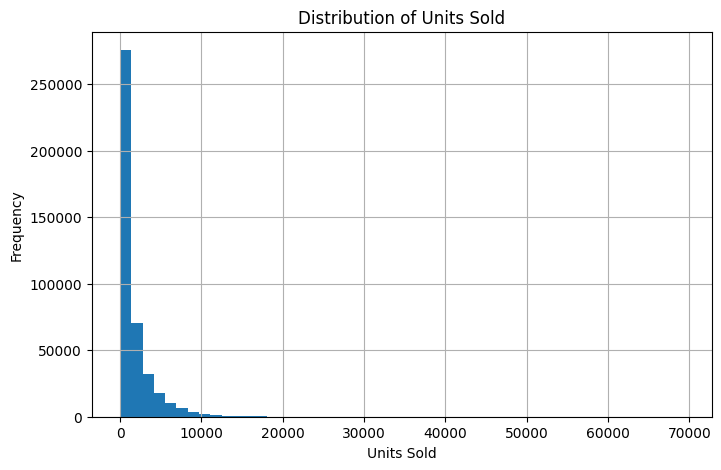

In [10]:
eda_df = df.copy()

eda_df["Weekly_Sales"] = eda_df["Weekly_Sales"].clip(lower=0)
eda_df["units_sold"] = (eda_df["Weekly_Sales"] / 10).round().astype(int)

plt.figure(figsize=(8, 5))
eda_df["units_sold"].hist(bins=50)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

**Graph explanation:**  
The graph shows that most of the sales values are in the lower range, because the bars on the left side are much higher. As the sales value increases, the number of records gradually decreases. This means high sales values happened less frequently in the dataset.


## EDA 2: Average Retail Sales by Store Type

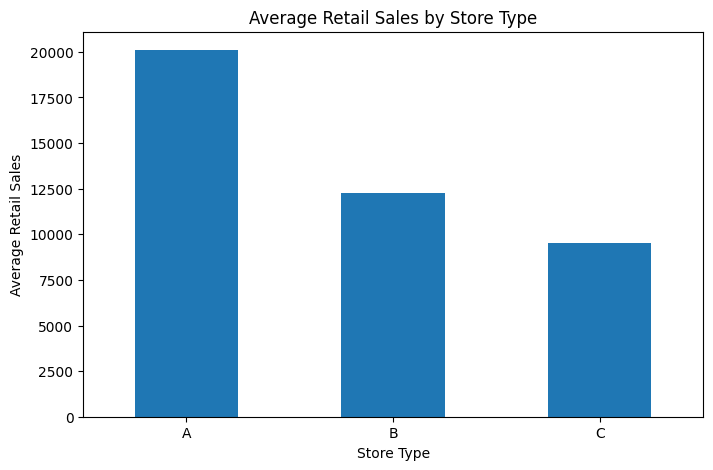

In [11]:
store_type_sales = df.groupby("Type")["Weekly_Sales"].mean()

plt.figure(figsize=(8, 5))
store_type_sales.plot(kind="bar")
plt.title("Average Retail Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that Store Type A has the highest average retail sales compared to Store Types B and C. Store Type B has moderate sales, while Store Type C has the lowest average sales among the three categories. This indicates that retail demand behavior varies across different store types.


## EDA 3: Holiday vs Non-Holiday Sales

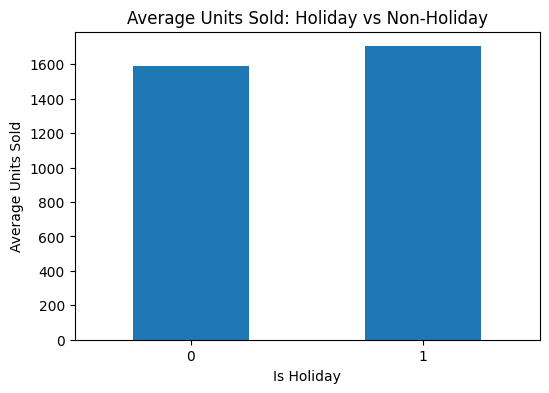

In [12]:
eda_df["is_holiday"] = eda_df["IsHoliday"].astype(int)

avg_sales_by_holiday = eda_df.groupby("is_holiday")["units_sold"].mean()

plt.figure(figsize=(6, 4))
avg_sales_by_holiday.plot(kind="bar")
plt.title("Average Units Sold: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that average units sold during holiday periods are slightly higher than non-holiday periods. This indicates that customer demand increases during holidays, which may create higher inventory requirements during those periods.


## EDA 4: Promotion Status vs Sales

Markdown columns are used as a proxy for promotion activity. If any markdown value is greater than zero, promotion is considered active.


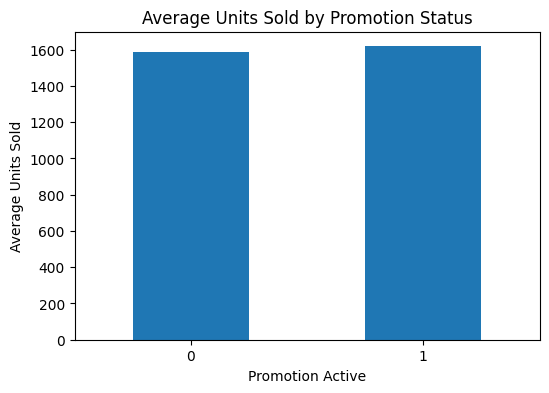

In [13]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    if col not in eda_df.columns:
        eda_df[col] = 0
    eda_df[col] = eda_df[col].fillna(0)

eda_df["promotion"] = (
    (eda_df["MarkDown1"] > 0)
    | (eda_df["MarkDown2"] > 0)
    | (eda_df["MarkDown3"] > 0)
    | (eda_df["MarkDown4"] > 0)
    | (eda_df["MarkDown5"] > 0)
).astype(int)

avg_sales_by_promotion = eda_df.groupby("promotion")["units_sold"].mean()

plt.figure(figsize=(6, 4))
avg_sales_by_promotion.plot(kind="bar")
plt.title("Average Units Sold by Promotion Status")
plt.xlabel("Promotion Active")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that average units sold are slightly higher when promotions are active compared to non-promotional periods. This suggests that promotions may increase customer purchasing behavior, although the difference is not extremely large in the overall dataset.


## EDA 5: Top Departments by Average Retail Sales

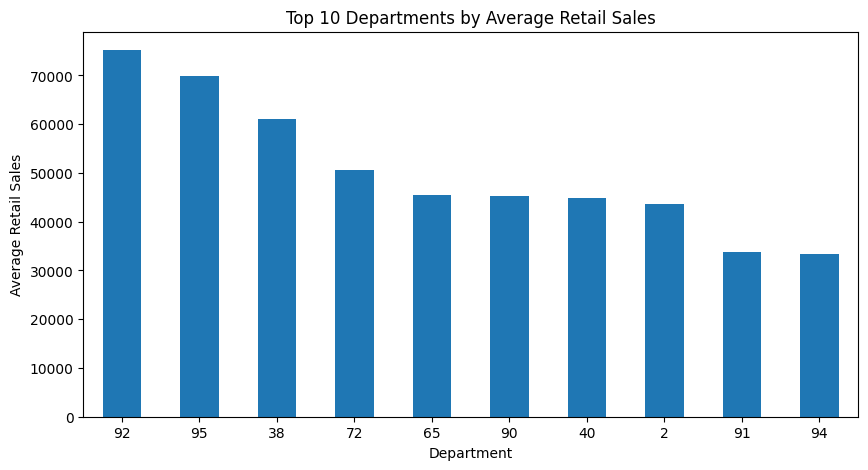

In [14]:
top_departments = (
    df.groupby("Dept")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_departments.plot(kind="bar")
plt.title("Top 10 Departments by Average Retail Sales")
plt.xlabel("Department")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that some departments have much higher average sales than others. This means demand is not equal across all departments, so department-level information is important for forecasting and inventory planning.


## EDA 6: Temperature vs Sales

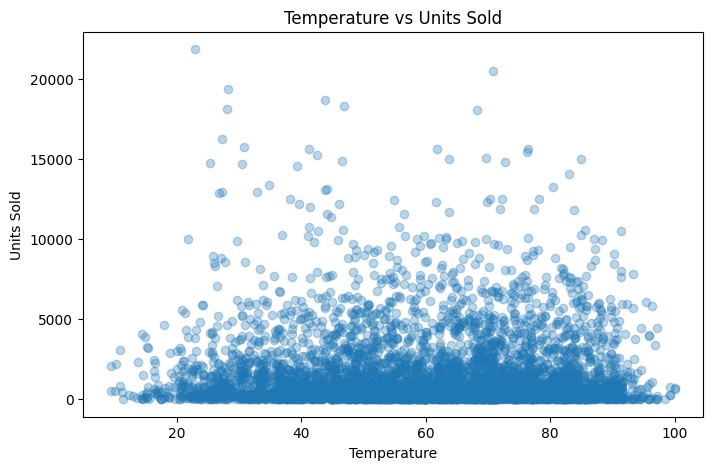

In [15]:
sample_for_scatter = eda_df.sample(min(5000, len(eda_df)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_for_scatter["Temperature"], sample_for_scatter["units_sold"], alpha=0.3)
plt.title("Temperature vs Units Sold")
plt.xlabel("Temperature")
plt.ylabel("Units Sold")
plt.show()

**Graph explanation:**  
The graph shows that sales values are spread across different temperature levels. There is no simple straight-line relationship, which means temperature alone cannot explain demand, but it can still be useful together with other features.


# 3. Data Preparation

This step prepares the dataset for machine learning.

Main tasks:

- clean and transform dates  
- create retail demand target  
- create operational features  
- simulate inventory-related variables  
- encode categorical variables  
- remove leakage-prone variables from training features  


In [16]:
final_df = df.copy()

final_df["Date"] = pd.to_datetime(final_df["Date"])
final_df["date"] = final_df["Date"].dt.strftime("%Y-%m-%d")

# This is mostly Friday because the dataset is weekly aggregated.
final_df["day_of_week"] = final_df["Date"].dt.dayofweek
final_df["is_weekend"] = final_df["day_of_week"].isin([5, 6]).astype(int)

final_df["product_name"] = "Dept_" + final_df["Dept"].astype(str)
final_df["category"] = final_df["Type"].astype(str)
final_df["store_id"] = final_df["Store"].astype(int)

final_df["is_holiday"] = final_df["IsHoliday"].astype(int)
final_df["temperature"] = final_df["Temperature"].fillna(final_df["Temperature"].median())

for col in markdown_cols:
    final_df[col] = final_df[col].fillna(0)

final_df["promotion"] = (
    (final_df["MarkDown1"] > 0)
    | (final_df["MarkDown2"] > 0)
    | (final_df["MarkDown3"] > 0)
    | (final_df["MarkDown4"] > 0)
    | (final_df["MarkDown5"] > 0)
).astype(int)

final_df["Weekly_Sales"] = final_df["Weekly_Sales"].clip(lower=0)
final_df["units_sold"] = (final_df["Weekly_Sales"] / 10).round().astype(int)
final_df["unit_price"] = 10.0

final_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,date,day_of_week,is_weekend,product_name,category,store_id,is_holiday,temperature,promotion,units_sold,unit_price
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010-02-05,4,0,Dept_1,A,1,0,42.31,0,2492,10.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010-02-12,4,0,Dept_1,A,1,1,38.51,0,4604,10.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010-02-19,4,0,Dept_1,A,1,0,39.93,0,4160,10.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010-02-26,4,0,Dept_1,A,1,0,46.63,0,1940,10.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010-03-05,4,0,Dept_1,A,1,0,46.50,0,2183,10.0


## 3.1 Engineered Inventory and Waste-Risk Variables

The Walmart dataset does not contain real stock levels, expiry days, or actual food-waste quantities. Therefore, these variables are engineered for workflow demonstration and inventory decision-support analysis.

These variables should not be interpreted as direct food-waste measurements. They are used to demonstrate how demand forecasting can support **inventory assessment, waste-risk identification, and intelligent recommendation support**.


In [17]:
final_df["expiry_days"] = (
    10 - (final_df["Dept"].astype(int) % 10)
).clip(lower=1, upper=10)

stock_buffer = (
    30
    + final_df["is_holiday"] * 20
    + final_df["promotion"] * 15
    + final_df["is_weekend"] * 10
)

final_df["current_stock"] = (
    final_df["units_sold"] + stock_buffer
).round().astype(int)

overstock = (final_df["current_stock"] - final_df["units_sold"]).clip(lower=0)

final_df["waste_quantity"] = 0
final_df.loc[final_df["expiry_days"] <= 2, "waste_quantity"] = overstock * 0.40
final_df.loc[
    (final_df["expiry_days"] > 2) & (final_df["expiry_days"] <= 5),
    "waste_quantity"
] = overstock * 0.20
final_df.loc[final_df["expiry_days"] > 5, "waste_quantity"] = overstock * 0.10
final_df["waste_quantity"] = final_df["waste_quantity"].round().astype(int)

# Additional feature engineering used in the report and production preprocessing logic
final_df["stock_to_sales_ratio"] = final_df["current_stock"] / (final_df["units_sold"] + 1)
final_df["stock_to_sales_ratio"] = final_df["stock_to_sales_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 100)

stock_median = final_df["current_stock"].median()
sales_median = final_df["units_sold"].median()

final_df["is_high_stock"] = (final_df["current_stock"] > stock_median).astype(int)
final_df["is_low_demand"] = (final_df["units_sold"] < sales_median).astype(int)
final_df["short_expiry"] = (final_df["expiry_days"] <= 3).astype(int)
final_df["promotion_active"] = final_df["promotion"].astype(int)

final_df["waste_risk_score"] = (
    (final_df["stock_to_sales_ratio"] * 0.4)
    + (final_df["is_high_stock"] * 0.2)
    + (final_df["is_low_demand"] * 0.2)
    + (final_df["short_expiry"] * 0.2)
)
final_df["waste_risk_score"] = final_df["waste_risk_score"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 100)

final_df[[
    "product_name", "category", "units_sold", "current_stock", "expiry_days",
    "stock_to_sales_ratio", "is_high_stock", "is_low_demand", "short_expiry",
    "promotion_active", "waste_risk_score", "waste_quantity"
]].head()


,product_name,category,units_sold,current_stock,expiry_days,stock_to_sales_ratio,is_high_stock,is_low_demand,short_expiry,promotion_active,waste_risk_score,waste_quantity
0,Dept_1,A,2492,2522,9,1.011633,1,0,0,0,0.604653,3
1,Dept_1,A,4604,4654,9,1.010641,1,0,0,0,0.604256,5
2,Dept_1,A,4160,4190,9,1.006969,1,0,0,0,0.602788,3
3,Dept_1,A,1940,1970,9,1.014941,1,0,0,0,0.605976,3
4,Dept_1,A,2183,2213,9,1.013278,1,0,0,0,0.605311,3


## 3.2 Feature Encoding and Final Training Dataset

The forecasting model uses the same core feature structure as the production training pipeline. Leakage-prone inventory variables such as `current_stock`, `waste_quantity`, and `waste_risk_score` are kept for inventory analysis and recommendation support, but they are not used directly as model inputs for demand prediction.


In [18]:
from sklearn.preprocessing import LabelEncoder

product_encoder = LabelEncoder()
category_encoder = LabelEncoder()

final_df["product_encoded"] = product_encoder.fit_transform(final_df["product_name"].astype(str))
final_df["category_encoded"] = category_encoder.fit_transform(final_df["category"].astype(str))

FEATURE_COLUMNS = [
    "product_encoded",
    "category_encoded",
    "store_id",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "promotion",
    "temperature",
    "unit_price",
    "expiry_days",
    "short_expiry",
    "promotion_active",
]

TARGET_COLUMN = "units_sold"

model_df = final_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Final modeling dataset shape:", model_df.shape)
model_df.head()


Final modeling dataset shape: (421570, 13)


,product_encoded,category_encoded,store_id,day_of_week,is_weekend,is_holiday,promotion,temperature,unit_price,expiry_days,short_expiry,promotion_active,units_sold
0,0,0,1,4,0,0,0,42.31,10.0,9,0,0,2492
1,0,0,1,4,0,1,0,38.51,10.0,9,0,0,4604
2,0,0,1,4,0,0,0,39.93,10.0,9,0,0,4160
3,0,0,1,4,0,0,0,46.63,10.0,9,0,0,1940
4,0,0,1,4,0,0,0,46.50,10.0,9,0,0,2183


**Important note about leakage and report consistency:**  
`current_stock`, `waste_quantity`, `stock_to_sales_ratio`, `is_high_stock`, `is_low_demand`, and `waste_risk_score` are used for inventory analysis, waste-risk estimation, and recommendation support. They are not used as direct demand forecasting inputs because some of them are derived from sales behavior. This keeps the demand forecasting model more realistic while still allowing inventory decision-support analysis after prediction.


## 3.3 Feature Correlation Heatmap

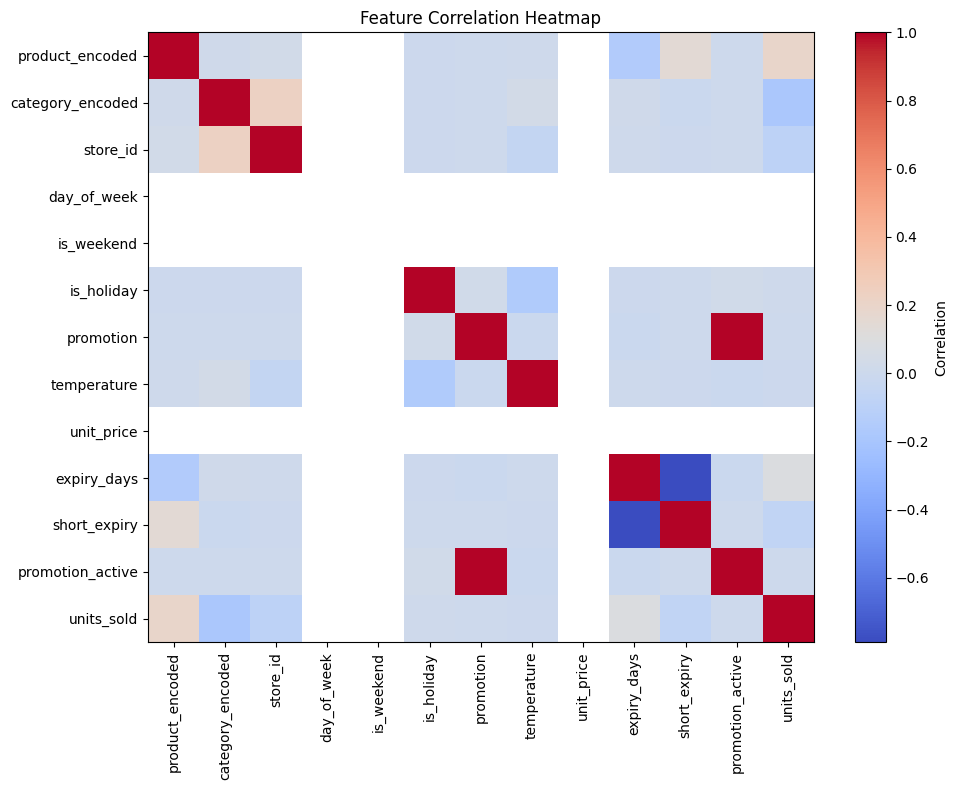

In [19]:
corr_df = model_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Graph explanation:**  
The heatmap shows how the numerical features are related to each other. Stronger colors indicate stronger relationships. This helps check whether any feature has a strong connection with demand or whether some features are too closely related to each other.


# 4. Modeling

The model predicts `units_sold`, which represents retail demand.

Two supervised regression models are trained and compared:

- RandomForestRegressor
- XGBoostRegressor

The notebook uses chronological train-test splitting and TimeSeriesSplit cross-validation to provide an evaluation that is more appropriate for retail data with a temporal structure.


In [20]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# Sort chronologically before model evaluation.
modeling_data = final_df.sort_values("Date").copy()
modeling_data = modeling_data.replace([np.inf, -np.inf], np.nan).fillna(0)

X = modeling_data[FEATURE_COLUMNS]
y = modeling_data[TARGET_COLUMN]

# Chronological 80/20 train-test split.
split_index = int(len(modeling_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

models = {
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoostRegressor": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )
}

tscv = TimeSeriesSplit(n_splits=3)

results = []
trained_models = {}
predictions_store = {}

for model_name, model in models.items():
    print(f"Training model: {model_name}")

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    test_r2 = r2_score(y_test, test_predictions)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    cv_rmse = -cv_scores

    generalization_gap = test_rmse - train_rmse

    trained_models[model_name] = model
    predictions_store[model_name] = test_predictions

    results.append({
        "Model": model_name,
        "Test MAE": round(test_mae, 4),
        "Test RMSE": round(test_rmse, 4),
        "Test R²": round(test_r2, 4),
        "Train RMSE": round(train_rmse, 4),
        "CV RMSE Mean": round(cv_rmse.mean(), 4),
        "CV RMSE Std": round(cv_rmse.std(), 4),
        "Generalization Gap": round(generalization_gap, 4)
    })

comparison_df = pd.DataFrame(results).sort_values("CV RMSE Mean").reset_index(drop=True)

best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions_store[best_model_name]

print("\nModel training completed.")
print("Best model:", best_model_name)
print("Selection metric: CV RMSE")
display(comparison_df)


Training model: RandomForestRegressor
Training model: XGBoostRegressor

Model training completed.
Best model: RandomForestRegressor
Selection metric: CV RMSE


,Model,Test MAE,Test RMSE,Test R²,Train RMSE,CV RMSE Mean,CV RMSE Std,Generalization Gap
0,RandomForestRegressor,229.3513,536.8264,0.9402,271.1509,803.3356,230.5497,265.6756
1,XGBoostRegressor,399.8589,649.8041,0.9123,813.2550,898.3018,207.6363,-163.4509


# 5. Evaluation

The evaluation compares both forecasting models using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Train RMSE
- TimeSeriesSplit Cross-Validation RMSE
- Generalization Gap

The final model is selected using **Cross-Validation RMSE** rather than relying only on one test split. The production implementation in `src/train.py` remains the authoritative source for the final report metrics and saved model artifacts.


## 5.1 Model Comparison and Final Model Selection

Random Forest and XGBoost are evaluated using chronological splitting and TimeSeriesSplit cross-validation. The comparison table below is generated from the model results produced during notebook execution.


In [21]:
display(comparison_df)

selected_model_summary = pd.DataFrame([{
    "Selected Model": best_model_name,
    "Selection Rule": "Lowest Cross-Validation RMSE",
    "Purpose": "Demand forecasting and subsequent inventory decision-support analysis"
}])

display(selected_model_summary)


,Model,Test MAE,Test RMSE,Test R²,Train RMSE,CV RMSE Mean,CV RMSE Std,Generalization Gap
0,RandomForestRegressor,229.3513,536.8264,0.9402,271.1509,803.3356,230.5497,265.6756
1,XGBoostRegressor,399.8589,649.8041,0.9123,813.2550,898.3018,207.6363,-163.4509


,Selected Model,Selection Rule,Purpose
0,RandomForestRegressor,Lowest Cross-Validation RMSE,Demand forecasting and subsequent inventory de...


**Model selection explanation:**  
The final model is selected using the lowest mean TimeSeriesSplit cross-validation RMSE. Test MAE, Test RMSE, R², Train RMSE, cross-validation variability, and the generalization gap are also reviewed to provide a broader evaluation of forecasting performance.

The final dissertation metrics should remain aligned with the production training pipeline in `src/train.py`.


### 5.2 Actual vs Predicted Demand

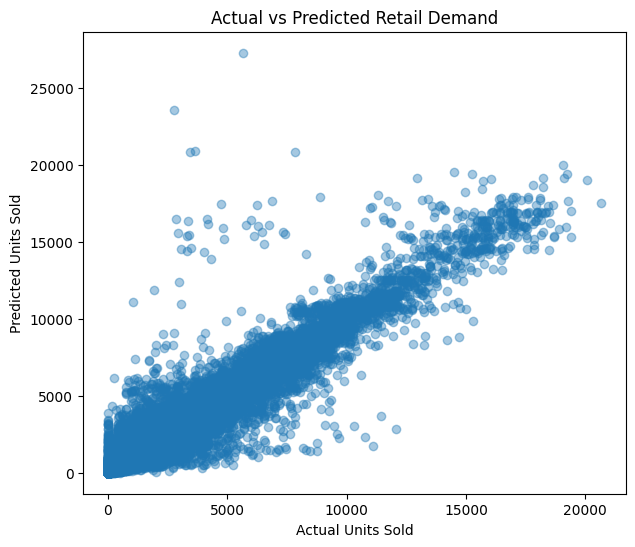

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.title("Actual vs Predicted Retail Demand")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.show()

**Graph explanation:**  
The graph compares actual demand values with predicted demand values. Points closer to a diagonal pattern indicate better prediction performance. This helps visually check whether the model is following the real demand pattern.


## 5.3 Prediction Error Distribution

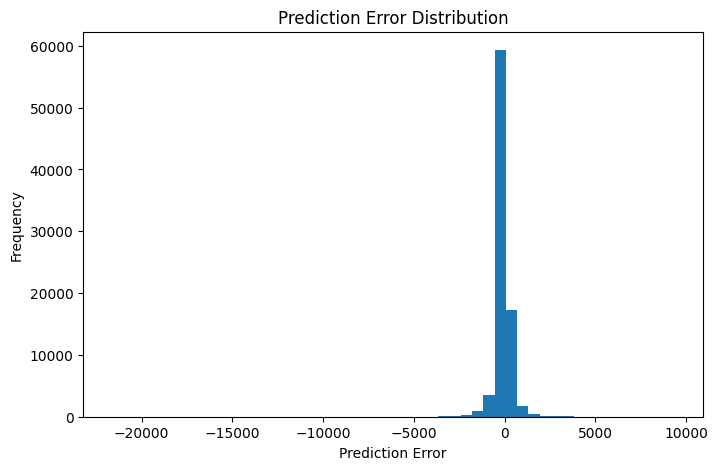

In [23]:
errors = y_test - best_predictions

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

**Graph explanation:**  
The error distribution shows how far the model predictions are from the actual values. If most errors are close to zero, it means the model is making many predictions near the actual demand values.


## 5.4 Feature Importance

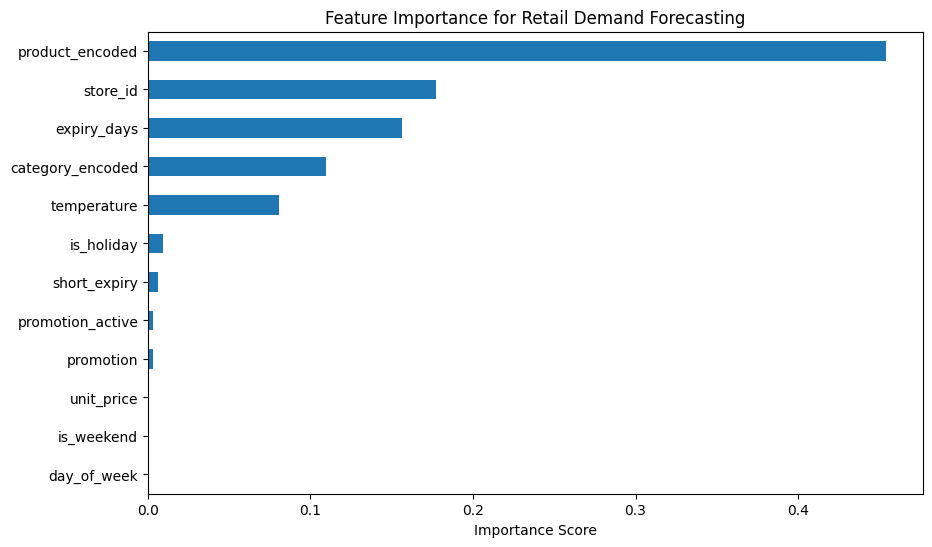

In [24]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=FEATURE_COLUMNS
    ).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    feature_importance.plot(kind="barh")
    plt.title("Feature Importance for Retail Demand Forecasting")
    plt.xlabel("Importance Score")
    plt.show()
else:
    print("The selected model does not provide feature_importances_.")

**Graph explanation:**  
The feature importance graph shows which input variables the model used most for forecasting demand. Higher importance means the feature contributed more to the model’s prediction decisions.


# 5.5 Inventory Assessment and Intelligent Recommendation Support

After demand prediction, the framework combines forecasting outputs with inventory-related information to produce practical inventory guidance.

The current implementation uses **predefined inventory assessment rules**, not a generative LLM. The recommendation logic considers predicted demand, current stock, expiry-related conditions, and waste-risk indicators to generate interpretable suggestions such as:

- increase replenishment when predicted demand exceeds stock
- reduce future ordering or monitor inventory when overstock risk is identified
- use promotion or stock redistribution when excess inventory is combined with short expiry
- maintain current planning when inventory conditions remain stable

LLM-assisted recommendations are considered a future extension for more context-aware explanations.


In [25]:
# Build a small recommendation demonstration using predictions from the best notebook model.
recommendation_sample = final_df.loc[y_test.index].copy()
recommendation_sample["predicted_units_sold"] = np.round(best_predictions).astype(int)

# Simple risk level based on stock, demand, and expiry condition
recommendation_sample["predicted_stock_gap"] = recommendation_sample["current_stock"] - recommendation_sample["predicted_units_sold"]

conditions = [
    (recommendation_sample["short_expiry"] == 1) & (recommendation_sample["predicted_stock_gap"] > 0),
    (recommendation_sample["predicted_stock_gap"] > recommendation_sample["predicted_units_sold"] * 0.30),
    (recommendation_sample["predicted_stock_gap"] < 0),
]
choices = ["High", "Medium", "Low Stock"]
recommendation_sample["waste_risk_level"] = np.select(conditions, choices, default="Low")


def generate_inventory_recommendation(row):
    if row["waste_risk_level"] == "High":
        return "High waste-risk: consider promotion, discounting, or reducing stock."
    if row["waste_risk_level"] == "Medium":
        return "Possible overstock: monitor demand and avoid extra replenishment."
    if row["waste_risk_level"] == "Low Stock":
        return "Demand may exceed stock: consider replenishment."
    return "Inventory condition is stable: maintain current planning."

recommendation_sample["inventory_recommendation"] = recommendation_sample.apply(
    generate_inventory_recommendation,
    axis=1
)

recommendation_sample[[
    "product_name", "category", "units_sold", "predicted_units_sold", "current_stock",
    "expiry_days", "waste_risk_level", "inventory_recommendation"
]].head(10)


,product_name,category,units_sold,predicted_units_sold,current_stock,expiry_days,waste_risk_level,inventory_recommendation
247015,Dept_1,A,2589,2009,2634,9,Medium,Possible overstock: monitor demand and avoid e...
106966,Dept_92,A,9169,8063,9214,8,Low,Inventory condition is stable: maintain curren...
224783,Dept_79,B,2845,3038,2890,1,Low Stock,Demand may exceed stock: consider replenishment.
151521,Dept_26,B,194,229,239,4,Low,Inventory condition is stable: maintain curren...
31205,Dept_12,A,756,1015,801,8,Low Stock,Demand may exceed stock: consider replenishment.
351681,Dept_80,C,1043,1107,1088,10,Low Stock,Demand may exceed stock: consider replenishment.
419567,Dept_79,B,1437,1469,1482,1,High,"High waste-risk: consider promotion, discounti..."
407456,Dept_24,C,1,2,46,6,Medium,Possible overstock: monitor demand and avoid e...
237926,Dept_6,B,275,248,320,4,Low,Inventory condition is stable: maintain curren...
263205,Dept_52,A,202,340,247,8,Low Stock,Demand may exceed stock: consider replenishment.


# 6. Deployment and Production-Oriented Forecasting Workflow

The notebook demonstrates the CRISP-DM analytical workflow. The full project implementation also includes production-oriented components.

Main implementation files:

- `src/main.py`: FastAPI backend
- `src/external_client.py`: sends simulated external retail events through the API
- `src/live_ingestion.py`: generates normal and shifted retail events
- `src/preprocess.py`: preprocessing pipeline
- `src/train.py`: Random Forest and XGBoost model comparison, TimeSeriesSplit evaluation, and model saving
- `src/inventory_assessment.py`: inventory assessment
- `src/llm_recommendation.py`: rule-based intelligent recommendation support
- `src/drift_detection.py`: feature-drift monitoring
- `src/auto_retrain.py`: automatic retraining
- `src/frontend.py`: Streamlit dashboard

Production-style workflow:

Historical Walmart Data
→ Preprocessing + Feature Engineering
→ Random Forest + XGBoost
→ TimeSeriesSplit Evaluation
→ Best Model Selection
→ FastAPI Prediction
→ Inventory Assessment
→ Waste-Risk Identification
→ Intelligent Recommendation
→ Monitoring
→ Drift Detection
→ Automatic Retraining
→ Model Versioning
→ Streamlit Dashboard

Simulated external retail events enter separately through:
External Client → POST `/sales-event` → FastAPI → SQLite


## 6.1 Simple Drift Detection Demonstration

This example demonstrates the same relative mean-shift concept used by the production drift-monitoring implementation. It compares a historical reference window with a more recent current window for selected operational variables.


In [26]:
reference_window = final_df[
    ["units_sold", "current_stock", "temperature", "waste_quantity"]
].tail(1000).copy()

current_window = reference_window.sample(300, random_state=42).copy()

# Create shifted operational conditions for demonstration.
current_window["current_stock"] = current_window["current_stock"] + 250
current_window["units_sold"] = (current_window["units_sold"] * 0.1).round()
current_window["waste_quantity"] = current_window["waste_quantity"] + 50

drift_rows = []
threshold = 0.15

for col in reference_window.columns:
    ref_mean = reference_window[col].mean()
    cur_mean = current_window[col].mean()

    if ref_mean == 0:
        drift_score = 0.0
    else:
        drift_score = abs(cur_mean - ref_mean) / abs(ref_mean)

    drift_detected = drift_score > threshold

    drift_rows.append({
        "feature": col,
        "reference_mean": round(ref_mean, 4),
        "current_mean": round(cur_mean, 4),
        "drift_score": round(drift_score, 4),
        "threshold": threshold,
        "drift_detected": drift_detected
    })

drift_df = pd.DataFrame(drift_rows)
drift_df


,feature,reference_mean,current_mean,drift_score,threshold,drift_detected
0,units_sold,1903.332,196.4167,0.8968,0.15,True
1,current_stock,1940.347,2250.9833,0.1601,0.15,True
2,temperature,57.756,57.1676,0.0102,0.15,False
3,waste_quantity,6.157,56.2333,8.1332,0.15,True


**Explanation:**  
The drift table compares the mean of a 1,000-record reference window with a 300-record current window. A relative mean-shift score greater than **0.15** marks the feature as drifted. The production implementation uses this monitoring logic to support automatic retraining when significant drift is detected.


# Final Summary

This notebook follows CRISP-DM and demonstrates:

- business understanding
- data understanding and exploratory data analysis
- data preparation and feature engineering
- Random Forest and XGBoost model comparison
- chronological train-test evaluation
- TimeSeriesSplit cross-validation
- model evaluation and feature importance
- inventory assessment and rule-based intelligent recommendation support
- drift detection using a 0.15 threshold
- deployment and production-oriented forecasting workflow explanation

The notebook supports the final project direction by demonstrating that the project is not only a demand forecasting model. It is an **AI-driven retail demand forecasting and intelligent inventory decision-support framework** that connects forecasting with inventory assessment, waste-risk identification, recommendations, monitoring, automatic retraining, and operational deployment.

The Walmart dataset does not contain direct food-waste observations. Therefore, the project identifies **inventory-related waste risk** rather than claiming direct measurement of actual food-waste reduction.
